<h>패키지</h>

In [2]:
import pandas as pd
import numpy as np
import requests
import time

# 시각화 패키지
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 경고창 무시
import warnings
warnings.filterwarnings("ignore")

   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB 653.6 kB/s eta 0:00:24
   ---------------------------------------- 0.1/15.6 MB 1.1 MB/s eta 0:00:15
   ---------------------------------------- 0.2/15.6 MB 1.2 MB/s eta 0:00:14
    --------------------------------------- 0.2/15.6 MB 1.3 MB/s eta 0:00:13
    --------------------------------------- 0.3/15.6 MB 1.3 MB/s eta 0:00:13
    --------------------------------------- 0.4/15.6 MB 1.2 MB/s eta 0:00:13
   - -------------------------------------- 0.4/15.6 MB 1.3 MB/s eta 0:00:12
   - -------------------------------------- 0.5/15.6 MB 1.4 MB/s eta 0:00:12
   - -------------------------------------- 0.6/15.6 MB 1.4 MB/s eta 0:00:11
   - -------------------------------------- 0.7/15.6 MB 1.4 MB/s eta 0:00:11
   - -------------------------------------- 0.8/15.6 MB 1.5 MB/s eta 0:00:11
   -- -----


[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<h>Riot Account ID 정보 불러오기</h>

In [3]:
# API 키 갱신 확인 후 사용
api_key = "RGAPI-bfa150da-1813-4450-96a4-b637fc047bb8"

# 소환사 이름
gameName = "슈 닷"
tagLine = "77777"
account_url = f"https://asia.api.riotgames.com/riot/account/v1/accounts/by-riot-id/{gameName}/{tagLine}?api_key={api_key}"
account_r = requests.get(account_url)

account_r

<Response [200]>

<p>랭크 유저들의 summonerId 찾기</p>

In [4]:
# 티어는 실버 이상
tier1 = ["SILVER", "GOLD", "PLATINUM", "EMERALD", "DIAMOND"]
tier2 = ["master", "grandmaster", "challenger"]
division = ["I", "II", "III", "IV"]
page = 1

entries = pd.DataFrame()

for t in tier1:

    for div in division:
        rank_entries_url =f"https://kr.api.riotgames.com/lol/league/v4/entries/RANKED_SOLO_5x5/{t}/{div}?page=1&api_key={api_key}"
        rank_entries_r = requests.get(rank_entries_url)

        temp_entries = pd.json_normalize(rank_entries_r.json())

        entries = pd.concat([entries, temp_entries])

for t in tier2:
    rank_entries_url =f"https://kr.api.riotgames.com/lol/league/v4/{t}leagues/by-queue/RANKED_SOLO_5x5?api_key={api_key}"
    rank_entries_r = requests.get(rank_entries_url)

    temp_entries = pd.json_normalize(rank_entries_r.json()['entries'])
    temp_entries['tier'] = t.upper()

    entries = pd.concat([entries, temp_entries])

entries_col_lst = ["tier", "summonerId", "summonerName"]
entries = entries[entries_col_lst]

entries.to_csv("entries.csv", index=False,encoding='cp949')

In [5]:
entries

,tier,summonerId,summonerName
0,SILVER,bfEdP8Bqy5MxjzJG1w3Z7B4YFLQ3OYeQeDx5xcA1jAid1IBW,캣바보
1,SILVER,jKcPYN0VoOqkb_OcNNBbR-i1z3SGvm1HFu376u2FyNWBeaua,까까보조
2,SILVER,fJtW1gLMG623lekp4iZ0iA0RkM5l36O5AlFOgmVKtWHKcKsH,박태양조질사람
3,SILVER,cqRyfpNm0RDkctT91XXS3TihdMYYT3Um6ehQlmMI-2dTB33G,ZPDLSWKDDLS
4,SILVER,GbIu8gBm0BFjrQ4lXzNIX5gXeh5V0T3A27IizQ4xGZRYNAXH,공학미적분학
...,...,...,...
295,CHALLENGER,ETQyzro8HduUyiCaXwdK7bV8DeBmEy6j7cUGqRpGAzt4qq...,zcxsdasdas
296,CHALLENGER,UfcAikfHHmtyhZoB9bRTkpGydnMTNagmrOXcEDvnL6KGYt...,나의본색
297,CHALLENGER,CNTipNz35HcHo_GNdxy2WEd8kcqYteDJowQUMaA8hozYocY,깨가너무싫다
298,CHALLENGER,ebJ2RbX6SAvVMNgJ4EeN8Mha7L5IRF8dLXbASK-KBIH0FW...,손주녁


<p>summonerId to PUUID</p>

In [6]:
entries = pd.read_csv("entries.csv")
puuids = np.array([], dtype=str)

tier = "EMEARLD"
tier_entries = entries[entries['tier'] == tier]

for summonerId in tier_entries['summonerId']:
    puuid_url = f"https://kr.api.riotgames.com/lol/summoner/v4/summoners/{summonerId}?api_key={api_key}"
    puuid_r = requests.get(puuid_url)
    print(puuid_r)
    temp_puuid = puuid_r.json()['puuid']
    puuids = np.append(puuids, temp_puuid)

    # RATE LIMITS 피하기
    time.sleep(1)

tier_entries['puuid'] = puuids

tier_entries.to_csv(f"{tier}_entries.csv", index=False)


<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200

KeyError: 'puuid'

<h>Find Specific Ranked Matches by PUUID</h>

In [ ]:
tier_entries = pd.read_csv(f"{tier}_entries.csv")

# 매치 정보
tier_matchids = np.array([], dtype=str)
tier_puuids = np.array([], dtype=str)

count = 20

# 각 아이디 당 20개씩 matchid 불러오기
for puuid in tier_entries['puuid']:
    match_url = f"https://asia.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids?start=0&count={count}&api_key={api_key}"
    match_r = requests.get(match_url)
    
    # 한번에 20의 매치 정보
    temp_matchids = match_r.json()

    # puuid 20개씩 스택
    temp_puuids = np.array([], dtype=str)
    for i in range(count):
        temp_puuids = np.append(temp_puuids, puuid)

    # puuid stack
    tier_puuids = np.concatenate([tier_puuids, temp_puuids])
    
    # gameid stack
    tier_matchids = np.concatenate([tier_matchids, temp_matchids])

    # RATE LIMITS 피하기
    time.sleep(1)

tier_puuids_matchids = pd.DataFrame()
tier_puuids_matchids['matchid'] = tier_matchids
tier_puuids_matchids['puuid'] = tier_puuids

<p>Match Info 불러오기</p>

In [ ]:
my_game = pd.DataFrame()

for matchid in tier_puuids_matchids['matchid']:

    game_url = f"https://asia.api.riotgames.com/lol/match/v5/matches/{matchid}?api_key={api_key}"
    game_r = requests.get(game_url)

    # info가 없는 게임은 무시
    if 'info' not in game_r.json():
        continue

    # 랭크 게임만 사용
    if game_r.json()['info']['queueId'] != 420:
        continue

    # 랭크 게임만 사용
    if game_r.json()['info']['gameDuration'] < 300:
        continue

    puuid = tier_puuids_matchids[tier_puuids_matchids['matchid'] == matchid]['puuid'].values[0]

    # 10명의 대전 정보
    temp_game = pd.json_normalize(game_r.json()['info']['participants'])
    
    # 나의 participantid 확인
    summoner_lst = pd.json_normalize(game_r.json()['info']['participants'])
    me = summoner_lst[summoner_lst['puuid'] == puuid]
    
    # 나의 대전 정보
    temp_game = temp_game[temp_game['participantId'] == int(me['participantId'])]
    
    # 추가 정보 (게임 종류, 게임 시간)
    temp_game['queueId'] = game_r.json()['info']['queueId']
    temp_game['gameDuration'] = game_r.json()['info']['gameDuration']

    # 상대 라이너의 챔피언 이름
    temp_enemy_champ = summoner_lst[summoner_lst['individualPosition'] == str(me['individualPosition'].values[0])]
    temp_enemy_champ  = temp_enemy_champ[temp_enemy_champ['teamId'] != int(me['teamId'].values[0])]

    # 예외 처리
    if temp_enemy_champ['championName'].size == 0:
        continue

    temp_game['enemychampName'] = str(temp_enemy_champ['championName'].values[0])

    # 대전 정보 stack
    my_game = pd.concat([my_game, temp_game])
    
    # RATE LIMITS 피하기
    time.sleep(1)

# 시간이 오래걸리므로 csv로 저장
my_game.to_csv(f"{tier}_matchdata.csv", index=False)

<p>데이터 전처리</p>

In [ ]:
tier_games = pd.read_csv(f"{tier}_matchdata.csv")

# 특정 컬럼만 사용
col_lst = ["championName", "enemychampName", "gameDuration", 
            "win", "kills", "deaths", "assists", 
            "individualPosition", "item0", "item1", "item2", "item3", "item4", "item5", "item6",
            "perks.statPerks.defense", "perks.statPerks.flex", "perks.statPerks.offense", 
            "perks.styles"]

tier_games2 = tier_games[col_lst]

# KDA 추가하기
def cal_KDA(df):
    # perfect KDA는 death에 1을 추가
    if df["deaths"] == 0:
        adjust = 1
    else:
        adjust = 0
        
    KDA = (df["kills"] + df["assists"]) / (df["deaths"] + adjust)
    
    return round(KDA, 2)
    
tier_games2["K/D/A"] = tier_games2.apply(lambda x: cal_KDA(x), axis=1)

# 컬럼명 변경
rename_col_lst = {
    "teamId": "side", 
    "individualPosition": "position",
    "kills": "K",
    "deaths":"D",
    "assists":"A",
    "K/D/A": "KDA"
}

tier_games2.rename(columns = rename_col_lst, inplace = True)

# 게임종류, 진영 이름 적어주기, 게임시간 분단위
# tier_games2["side"] = tier_games2["side"].apply(lambda x: "Blue" if x == 100 else "Red")
tier_games2["gameDuration"] = tier_games2["gameDuration"] / 60

tier_games2.to_csv(f"DP_{tier}_matchdata.csv", index=False)

<p>챔피언 별 승률</p>

In [ ]:
tier_games = pd.read_csv(f"DP_{tier}_matchdata.csv")

# KDA 추가하기
def cal_KDA2(df):
    # perfect KDA는 death에 1을 추가
    if df["D"] == 0:
        adjust = 1
    else:
        adjust = 0
        
    KDA = (df["K"] + df["A"]) / (df["D"] + adjust)
    
    return round(KDA, 2)

# 승률
def ratio(x):
    return x.sum() / x.count() * 100

# 그룹별 집계
def group_statistic(df, group_lst, sort=False):
    # 판수, 승리수, 승률
    temp = df.groupby(group_lst)["win"].agg({'count', "sum", ratio}).reset_index()
    
    # 패배수 추가
    temp["lc"] = temp["count"] - temp["sum"]
    
    # 그룹별 KDA 추가
    kda = df.groupby(group_lst).sum().apply(lambda x: cal_KDA2(x), axis=1).values
    temp["kda"] = kda
    
    # 컬럼 순서 지정
    re = {"count":"total_count", "sum":"win_count", "lc":"lose_count", "ratio":"win_rate", "kda":"KDA"}
    temp = temp.rename(columns=re)
    temp = temp[group_lst + list(re.values())]
    
    # 정렬 옵션
    if sort != False:
        temp = temp.sort_values(by=[sort], ascending=False)    
    
    return temp

temp = group_statistic(tier_games, ["championName"], sort="win_rate")
temp[(temp["total_count"] >= 10)]

,championName,total_count,win_count,lose_count,win_rate,KDA
28,Fiora,12,11,1,91.666667,1.55
77,Morgana,11,9,2,81.818182,2.95
13,Brand,15,11,4,73.333333,3.81
149,Yuumi,27,19,8,70.370370,5.70
39,Illaoi,27,19,8,70.370370,1.93
...,...,...,...,...,...,...
115,Sivir,19,5,14,26.315789,1.90
122,Taliyah,12,3,9,25.000000,1.68
96,Rammus,13,3,10,23.076923,2.40
23,Ekko,10,2,8,20.000000,2.37


<p>학습시키기</p>

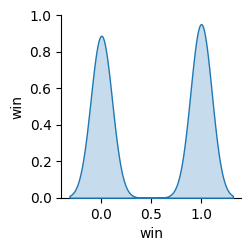

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from keras import layers

tier_games = pd.read_csv(f"DP_{tier}_matchdata.csv")

item_class_names = ["championName", "enemychampName",
            "win", "item0", "item1", "item2", "item3", "item4", "item5", "item6"]

perk_class_names = ["championName", "enemychampName",
            "win", "perks.statPerks.defense", "perks.statPerks.flex", "perks.statPerks.offense", 
            "perks.styles"]

# 챔피언 키 불러오기
champ_data_r = requests.get("https://ddragon.leagueoflegends.com/cdn/13.24.1/data/en_US/champion.json")
champ_data = champ_data_r.json()['data']

# 챔피언 이름을 키값으로 변경
for i in champ_data:
    tier_games.loc[tier_games['championName'] == i, 'championName'] = champ_data[i]['key']
    tier_games.loc[tier_games['enemychampName'] == i, 'enemychampName'] = champ_data[i]['key']

# 아이템과 룬 분리
tier_games_item = tier_games[item_class_names]
tier_games_perk = tier_games[perk_class_names]

